In [22]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
import pandas as pd
import numpy as np
internal_PDC_VS_MPC_dir = os.getcwd()
internal_June_3_2026_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..'))
print(f'The current working directory is : {internal_PDC_VS_MPC_dir}')
internal_MPC_data_dir = os.path.abspath(os.path.join(internal_June_3_2026_dir, 'June3_2026'))
print(f'The MPC data directory : {internal_MPC_data_dir}')
internal_PD_data_dir = os.path.abspath(os.path.join(internal_June_3_2026_dir, 'June3_2026'))
print(f'The PD data directory : {internal_PD_data_dir}')
internal_VTR_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..', '..'))
print(f'The VTR directory : {internal_VTR_dir}')
root_dir = os.path.abspath(os.path.join(internal_VTR_dir, '..'))
print(f'The root directory : {root_dir}')
internal_HT_dir = os.path.abspath(os.path.join(root_dir, '8_Hardware', 'Hardware_Testing'))
print(f'The internal HT directory : {internal_HT_dir}')
internal_HT_MPC_dir = os.path.abspath(os.path.join(internal_HT_dir, '2_MPC_Controllers'))
print(f'The internal HT MPC directory : {internal_HT_MPC_dir}')
internal_scripts_dir = os.path.abspath(os.path.join(internal_HT_MPC_dir, 'scripts'))
print(f'The internal scripts directory : {internal_scripts_dir}')
sys.path.append(internal_scripts_dir)
import H_Common_Params as CP

The current working directory is : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\June3_2026
The MPC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\June3_2026
The PD data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\June3_2026
The VTR directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results
The root directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control
The internal HT directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\8_Hardware\Hardware_Testing
The internal HT MPC directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cru

In [23]:
internal_PDC_FV_data_dir = os.path.abspath(os.path.join(internal_PD_data_dir, 'Processed_Data_PD_FV'))
internal_MPC_FV_data_dir = os.path.abspath(os.path.join(internal_MPC_data_dir, 'Processed_Data_MPC_FV'))
print(f'The PDC data directory : {internal_PDC_FV_data_dir}')
print(f'The MPC data directory : {internal_MPC_FV_data_dir}')


The PDC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\June3_2026\Processed_Data_PD_FV
The MPC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\June3_2026\Processed_Data_MPC_FV


In [24]:
# Print the names of the files in the PDC and MPC data directories to check if they are the same
print(f'PDC data files : {os.listdir(internal_PDC_FV_data_dir)}')
print(f'MPC data files 5kmph : {os.listdir(internal_MPC_FV_data_dir)}')
 

PDC data files : ['Data_Jun4_PD_10kph_FV1.csv', 'Data_Jun4_PD_10kph_FV2.csv', 'Data_Jun4_PD_5kph_FV1.csv']
MPC data files 5kmph : ['Data_Apr7_MPC_5kph_FV1.csv', 'Data_Jun4_MPC_10kph_FV1.csv', 'Data_Jun4_MPC_10kph_FV2.csv']


In [25]:
PDC_data_list = []
for i in range(len(os.listdir(internal_PDC_FV_data_dir))):
    PDC_data_list.append(pd.read_csv(os.path.join(internal_PDC_FV_data_dir, os.listdir(internal_PDC_FV_data_dir)[i])))
    
MPC_data_list = []
for i in range(len(os.listdir(internal_MPC_FV_data_dir))):
    MPC_data_list.append(pd.read_csv(os.path.join(internal_MPC_FV_data_dir, os.listdir(internal_MPC_FV_data_dir)[i])))


In [26]:
# Print the column names of the first dataframe in PDC_data_list and MPC_data_list to check if they are the same
print(f'PDC data columns : {PDC_data_list[0].columns}')
print(f'MPC data columns : {MPC_data_list[0].columns}')

PDC data columns : Index(['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)',
       'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)',
       'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)',
       'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)',
       'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph',
       'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean',
       'Ego_Position_clean', 'Obs_Position_clean'],
      dtype='object')
MPC data columns : Index(['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)',
       'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)',
       'Time(s)', 'Throttle_command', 'Time', 'Time_1s',
       'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)',
       'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)',
       'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean',
       'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean',
     

## For 5Kmph

In [27]:
# Selecting the file name for both PDC and MPC to plot them together.
PDC_file_name = os.listdir(internal_PDC_FV_data_dir)[2]    
MPC_file_name_5kmph = os.listdir(internal_MPC_FV_data_dir)[0]
# MPC_file_name_10kmph = os.listdir(internal_MPC_FV_data_dir_2)[0]
print(f'Selected PDC file name : {PDC_file_name}')
print(f'Selected MPC 5kmph file name : {MPC_file_name_5kmph}')
# print(f'Selected MPC 10kmph file name : {MPC_file_name_10kmph}')

Selected PDC file name : Data_Jun4_PD_5kph_FV1.csv
Selected MPC 5kmph file name : Data_Apr7_MPC_5kph_FV1.csv


PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Throttle_command', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']


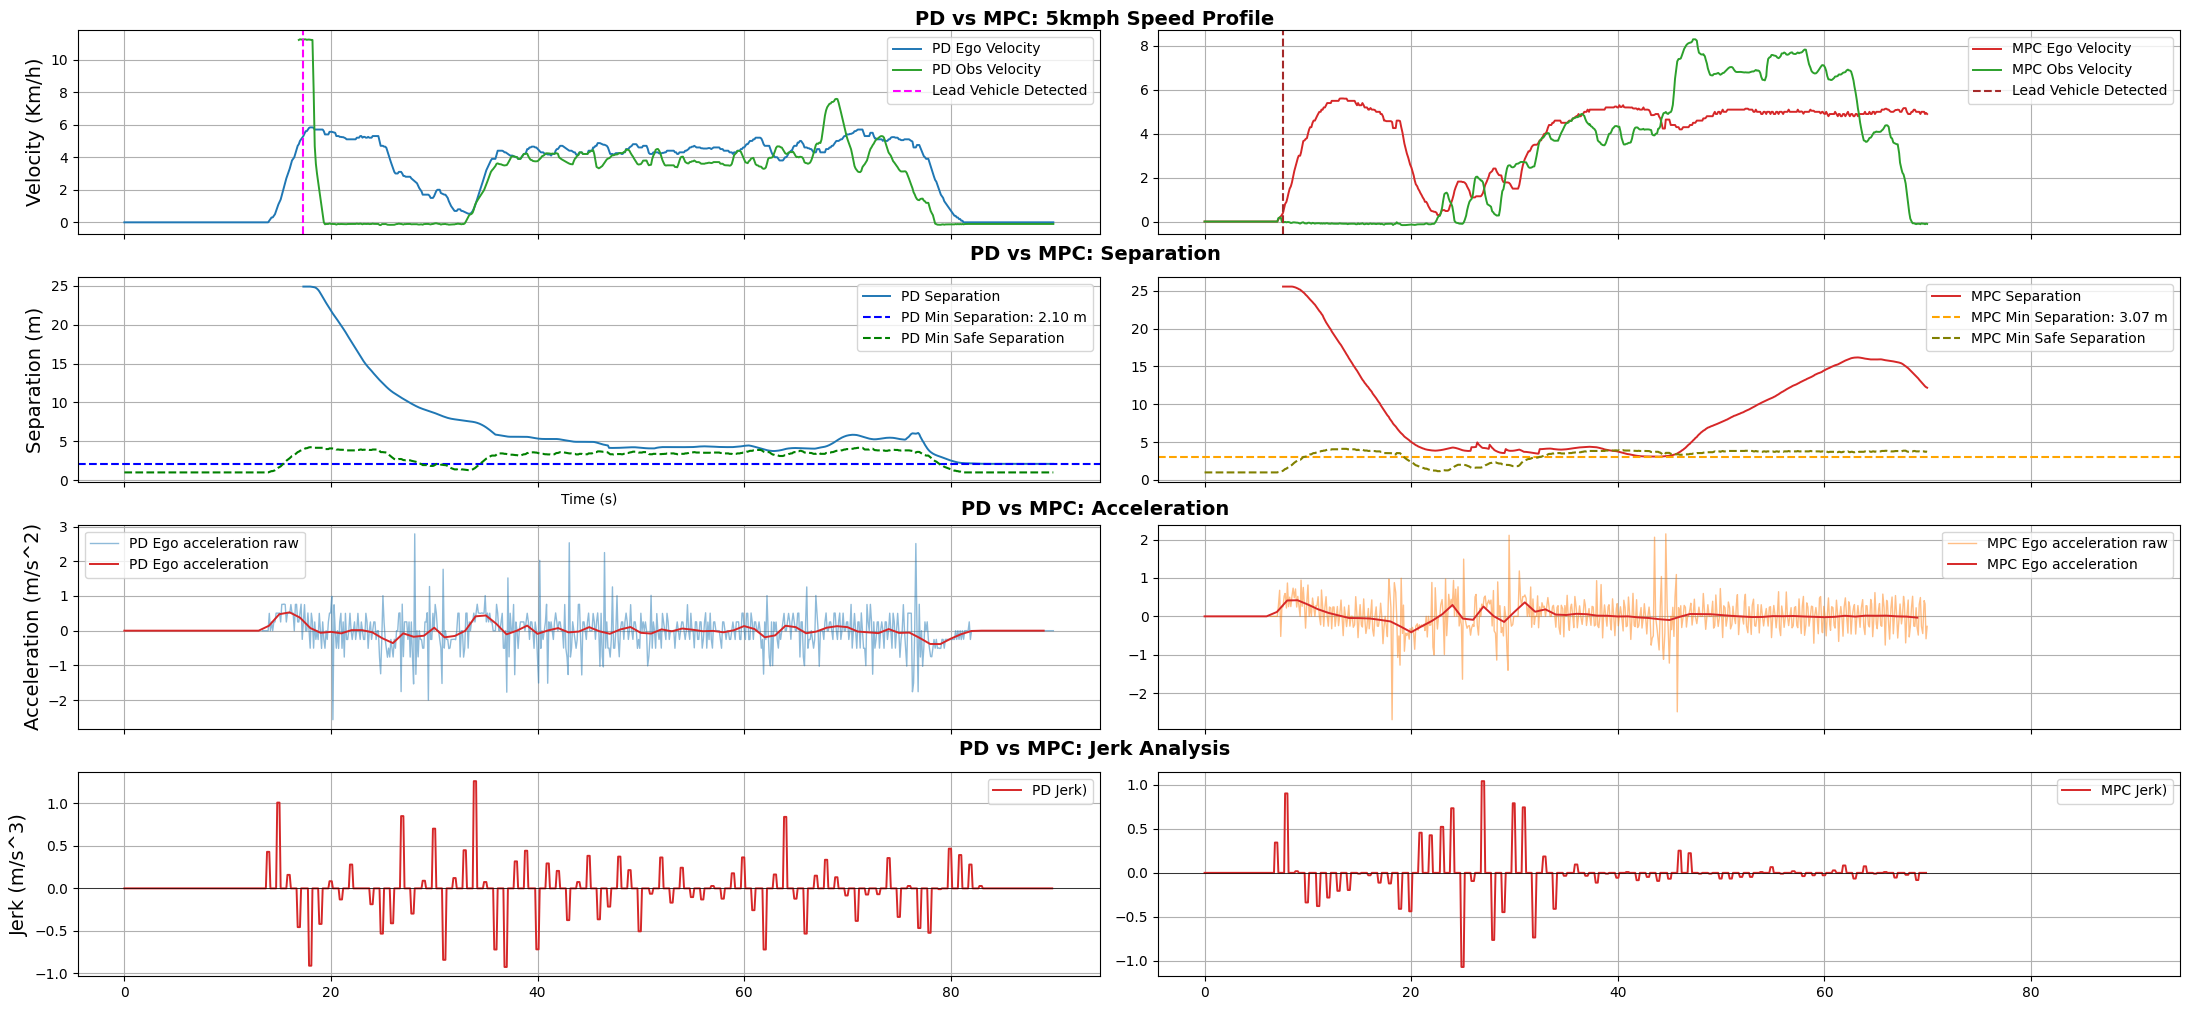

In [28]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir, MPC_file_name_5kmph))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
x_col_1 = "Time_1s" # Time in 1 second
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"
ego_acc_raw = "Ego_Acceleration_raw(m/s^2)"
ego_acc_clean = "Ego_Acceleration(m/s^2)"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(4, 2, figsize=(22,10), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0][0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0][0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:green", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:red", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:green", linewidth=1.4)
ax[0][0].set_ylabel("Velocity (Km/h)", fontsize=14)
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best")
ax[0][0].grid(True)
ax[0][1].grid(True)
# ax[0][0].set_title("PD vs MPC: 5kmph Speed Profile")

# Plot the detection line at the point where the obstacle is detected (when separation starts decreasing from a large value)
detection_time_pd = pdc_df[pdc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
detection_time_mpc = mpc_df[mpc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
ax[0][0].axvline(x=detection_time_pd, color='magenta', linestyle='--', label= 'Lead Vehicle Detected')
ax[0][1].axvline(x=detection_time_mpc, color='brown', linestyle='--', label='Lead Vehicle Detected')
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best") 


# Plot 2: Separation for PD and MPC
ax[1][0].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1][1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:red", linewidth=1.4)
ax[1][0].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1][1].axhline(y=minimum_separation_mpc, color='orange', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1][0].set_ylabel("Separation (m)", fontsize=14)
ax[1][0].set_xlabel("Time (s)")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")
ax[1][0].grid(True)
ax[1][1].grid(True)
# ax[1][0].set_title("PD vs MPC: Separation")

# Plot 3 : Acceleration for PD and MPC
ax[2][0].plot(pdc_df[x_col], pdc_df[ego_acc_raw], label="PD Ego acceleration raw", color="tab:blue", linewidth=1, alpha=0.5)
ax[2][0].plot(pdc_df[x_col_1], pdc_df[ego_acc_clean], label="PD Ego acceleration ", color="tab:red", linewidth=1.4)
ax[2][1].plot(mpc_df[x_col], mpc_df[ego_acc_raw], label="MPC Ego acceleration raw", color="tab:orange", linewidth=1 , alpha=0.5)
ax[2][1].plot(mpc_df[x_col_1], mpc_df[ego_acc_clean], label="MPC Ego acceleration", color="tab:red", linewidth=1.4)
ax[2][0].set_ylabel("Acceleration (m/s^2)", fontsize=14)
ax[2][0].legend(loc="best")
ax[2][1].legend(loc="best")
ax[2][0].grid(True)
ax[2][1].grid(True)

# Plot 4: Jerk for PD and MPC
# Calculate jerk values
pdc_acc_clean = pdc_df[ego_acc_clean].values
pdc_time_vals = pdc_df[x_col].values
pdc_dt = np.median(np.diff(pdc_time_vals)[np.diff(pdc_time_vals) > 0])
pdc_jerk = np.diff(pdc_acc_clean) / pdc_dt
pdc_jerk_time = pdc_time_vals[:-1]
pdc_jerk_smooth = np.convolve(pdc_jerk, np.ones(3)/3, mode='same')

mpc_acc_clean = mpc_df[ego_acc_clean].values
mpc_time_vals = mpc_df[x_col].values
mpc_dt = np.median(np.diff(mpc_time_vals)[np.diff(mpc_time_vals) > 0])
mpc_jerk = np.diff(mpc_acc_clean) / mpc_dt
mpc_jerk_time = mpc_time_vals[:-1]
mpc_jerk_smooth = np.convolve(mpc_jerk, np.ones(3)/3, mode='same')

# ax[3][0].plot(pdc_jerk_time, pdc_jerk, label="PD Jerk (Raw)", color="tab:blue", linewidth=1, alpha=0.5)
ax[3][0].plot(pdc_jerk_time, pdc_jerk_smooth, label="PD Jerk)", color="tab:red", linewidth=1.4)
ax[3][0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
# ax[3][1].plot(mpc_jerk_time, mpc_jerk, label="MPC Jerk (Raw)", color="tab:orange", linewidth=1, alpha=0.5)
ax[3][1].plot(mpc_jerk_time, mpc_jerk_smooth, label="MPC Jerk)", color="tab:red", linewidth=1.4)
ax[3][1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax[3][0].set_ylabel("Jerk (m/s^3)", fontsize=14)
ax[3][0].legend(loc="best")
ax[3][1].legend(loc="best")
ax[3][0].grid(True)
ax[3][1].grid(True)

fig.subplots_adjust(hspace=1)  # Reasonable spacing between rows
plt.tight_layout()

fig.text(0.5, 0.99, "PD vs MPC: 5kmph Speed Profile", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.755, "PD vs MPC: Separation", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.50, "PD vs MPC: Acceleration", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.26, "PD vs MPC: Jerk Analysis", ha='center', fontsize=14, weight='bold')

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1][0].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1][1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")


plt.tight_layout()
plt.show() 

## 10 Kmph

In [29]:
# Selecting the file name for both PDC and MPC to plot them together.
PDC_file_name = os.listdir(internal_PDC_FV_data_dir)[0]    
MPC_file_name_10kmph = os.listdir(internal_MPC_FV_data_dir)[1]
print(f'Selected PDC file name : {PDC_file_name}')
print(f'Selected MPC 10kmph file name : {MPC_file_name_10kmph}')

Selected PDC file name : Data_Jun4_PD_10kph_FV1.csv
Selected MPC 10kmph file name : Data_Jun4_MPC_10kph_FV1.csv


PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']


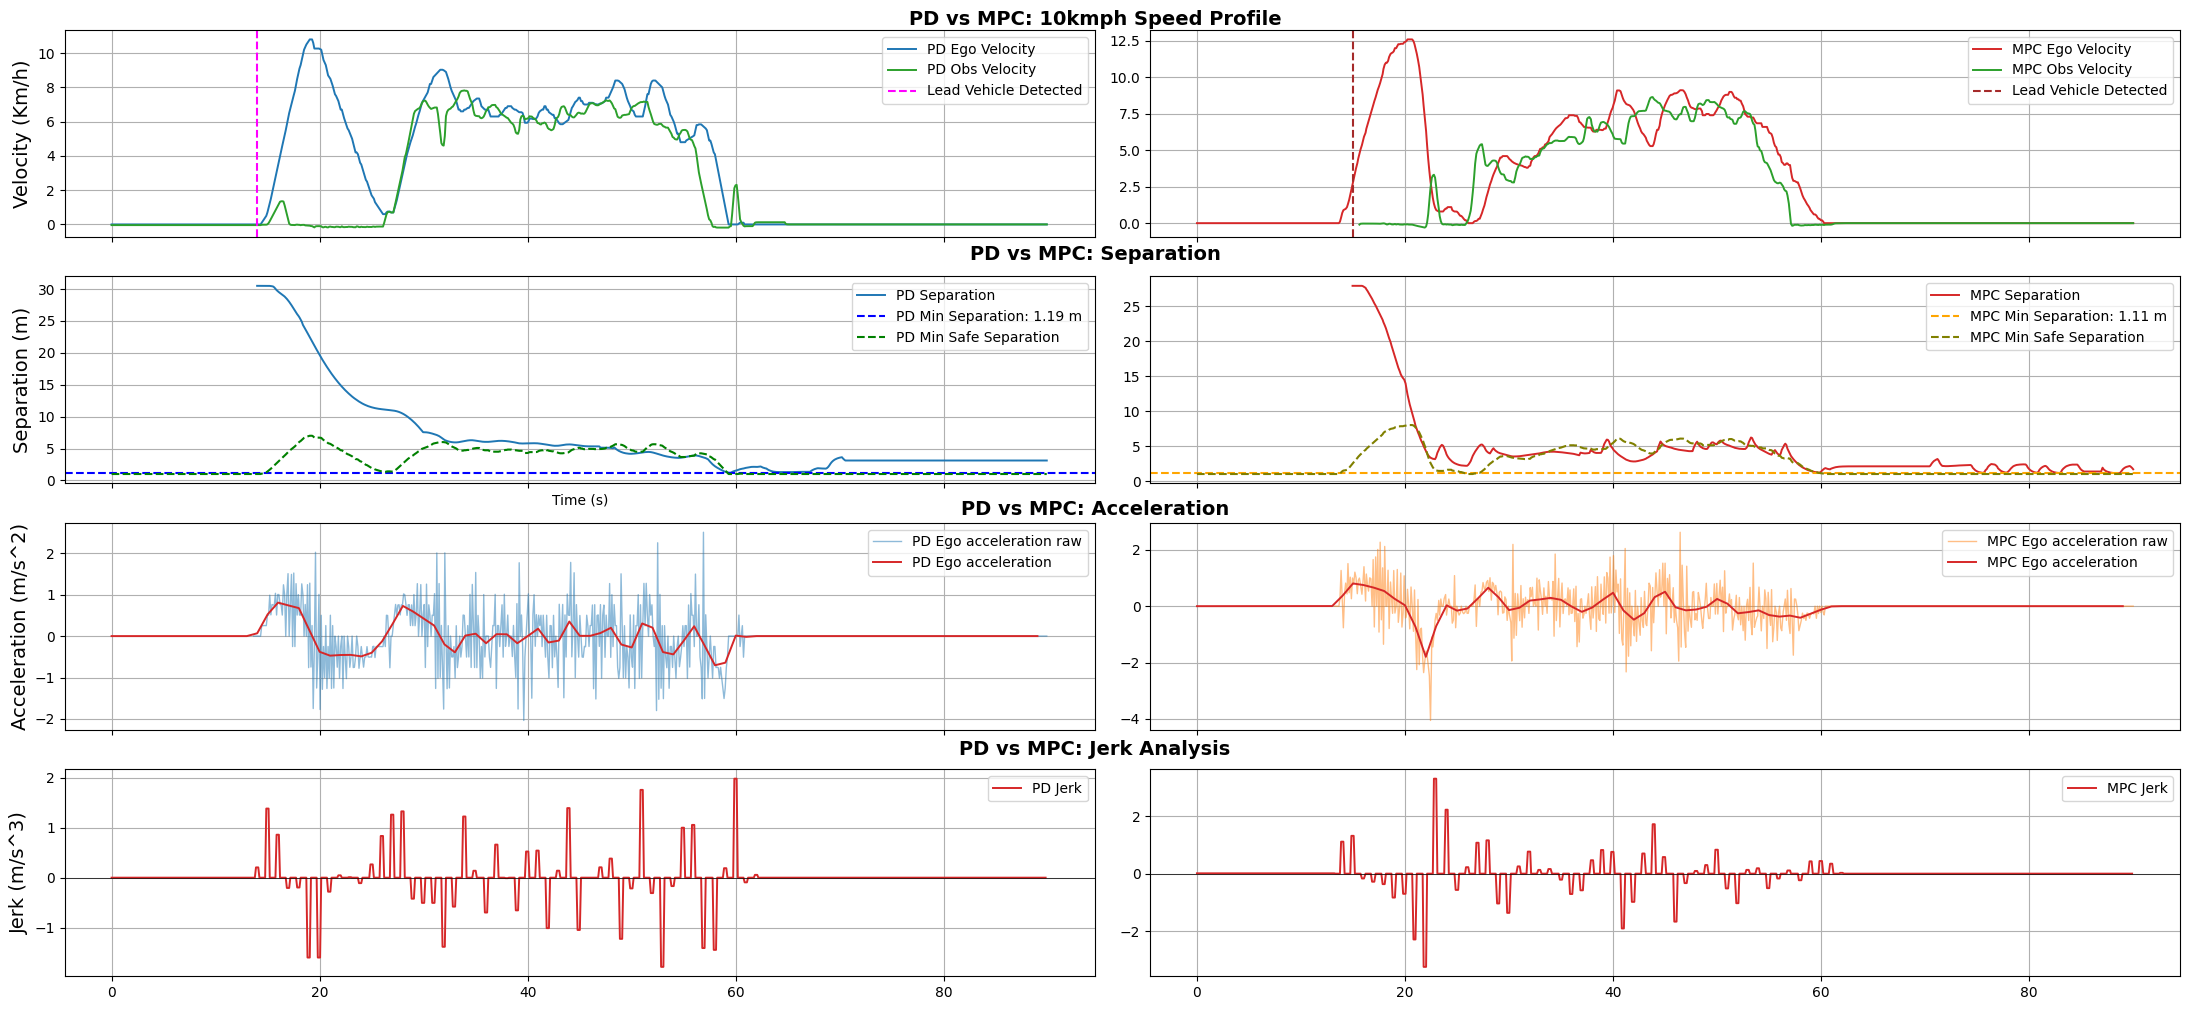

In [30]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir, MPC_file_name_10kmph))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
x_col_1 = "Time_1s" # Time in 1 second
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"
ego_acc_raw = "Ego_Acceleration_raw(m/s^2)"
ego_acc_clean = "Ego_Acceleration(m/s^2)"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(4, 2, figsize=(22, 10), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0][0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0][0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:green", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:red", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:green", linewidth=1.4)
ax[0][0].set_ylabel("Velocity (Km/h)", fontsize=14)
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best")
ax[0][0].grid(True)
ax[0][1].grid(True)
# ax[0][0].set_title("PD vs MPC: 10kmph Speed Profile")

# Plot the detection line at the point where the obstacle is detected (when separation starts decreasing from a large value)
detection_time_pd = pdc_df[pdc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
detection_time_mpc = mpc_df[mpc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
ax[0][0].axvline(x=detection_time_pd, color='magenta', linestyle='--', label= 'Lead Vehicle Detected')
ax[0][1].axvline(x=detection_time_mpc, color='brown', linestyle='--', label='Lead Vehicle Detected')
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best") 

# Plot 2: Separation for PD and MPC
ax[1][0].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1][1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:red", linewidth=1.4)
ax[1][0].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1][1].axhline(y=minimum_separation_mpc, color='orange', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1][0].set_ylabel("Separation (m)", fontsize=14)
ax[1][0].set_xlabel("Time (s)")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")
ax[1][0].grid(True)
ax[1][1].grid(True)
# ax[1][0].set_title("PD vs MPC: Separation")

# Plot 3 : Acceleration for PD and MPC
ax[2][0].plot(pdc_df[x_col], pdc_df[ego_acc_raw], label="PD Ego acceleration raw", color="tab:blue", linewidth=1, alpha=0.5)
ax[2][0].plot(pdc_df[x_col_1], pdc_df[ego_acc_clean], label="PD Ego acceleration ", color="tab:red", linewidth=1.4)
ax[2][1].plot(mpc_df[x_col], mpc_df[ego_acc_raw], label="MPC Ego acceleration raw", color="tab:orange", linewidth=1 , alpha=0.5)
ax[2][1].plot(mpc_df[x_col_1], mpc_df[ego_acc_clean], label="MPC Ego acceleration", color="tab:red", linewidth=1.4)
ax[2][0].set_ylabel("Acceleration (m/s^2)", fontsize=14)
ax[2][0].legend(loc="best")
ax[2][1].legend(loc="best")
ax[2][0].grid(True)
ax[2][1].grid(True)

# Plot 4: Jerk for PD and MPC
# Calculate jerk values
pdc_acc_clean = pdc_df[ego_acc_clean].values
pdc_time_vals = pdc_df[x_col].values
pdc_dt = np.median(np.diff(pdc_time_vals)[np.diff(pdc_time_vals) > 0])
pdc_jerk = np.diff(pdc_acc_clean) / pdc_dt
pdc_jerk_time = pdc_time_vals[:-1]
pdc_jerk_smooth = np.convolve(pdc_jerk, np.ones(3)/3, mode='same')

mpc_acc_clean = mpc_df[ego_acc_clean].values
mpc_time_vals = mpc_df[x_col].values
mpc_dt = np.median(np.diff(mpc_time_vals)[np.diff(mpc_time_vals) > 0])
mpc_jerk = np.diff(mpc_acc_clean) / mpc_dt
mpc_jerk_time = mpc_time_vals[:-1]
mpc_jerk_smooth = np.convolve(mpc_jerk, np.ones(3)/3, mode='same')

# ax[3][0].plot(pdc_jerk_time, pdc_jerk, label="PD Jerk (Raw)", color="tab:blue", linewidth=1, alpha=0.5)
ax[3][0].plot(pdc_jerk_time, pdc_jerk_smooth, label="PD Jerk", color="tab:red", linewidth=1.4)
ax[3][0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
# ax[3][1].plot(mpc_jerk_time, mpc_jerk, label="MPC Jerk (Raw)", color="tab:orange", linewidth=1, alpha=0.5)
ax[3][1].plot(mpc_jerk_time, mpc_jerk_smooth, label="MPC Jerk", color="tab:red", linewidth=1.4)
ax[3][1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax[3][0].set_ylabel("Jerk (m/s^3)", fontsize=14)
ax[3][0].legend(loc="best")
ax[3][1].legend(loc="best")
ax[3][0].grid(True)
ax[3][1].grid(True)

fig.subplots_adjust(hspace=1)  # Reasonable spacing between rows
plt.tight_layout()

fig.text(0.5, 0.99, "PD vs MPC: 10kmph Speed Profile", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.755, "PD vs MPC: Separation", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.50, "PD vs MPC: Acceleration", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.26, "PD vs MPC: Jerk Analysis", ha='center', fontsize=14, weight='bold')

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1][0].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1][1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")


plt.tight_layout()
plt.show() 

# Metrics Analysis & Visualization: FV Testing Campaign

In [31]:
import numpy as np
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

def calculate_metrics_fv(df, controller_name="Controller"):
    sep_col = "Separation_clean"
    ego_vel_col = "Ego_Velocity_clean"
    obs_vel_col = "Obs_Velocity_clean"
    ego_acc_raw = "Ego_Acceleration_raw(m/s^2)"
    ego_acc_clean = "Ego_Acceleration(m/s^2)"
    time_col = "Time(s)"

    min_sep = df[sep_col].min()
    mean_sep = df[sep_col].mean()
    std_sep = df[sep_col].std()

    rms_acc = np.sqrt(np.mean(df[ego_acc_clean]**2))

    acc_smooth = df[ego_acc_clean].values
    dt = np.diff(df[time_col].values)
    dt = np.median(dt[dt > 0])
    jerk = np.diff(acc_smooth) / dt
    mean_jerk = np.mean(np.abs(jerk))
    max_jerk = np.max(np.abs(jerk))

    ego_vel = df[ego_vel_col].values
    obs_vel = df[obs_vel_col].values
    vel_error = ego_vel - obs_vel

    # Apply obs_vel > 1.0 m/s filter for data quality
    valid_vel_idx = obs_vel > 1.0
    
    # Overshoot calculation with filtering
    overshoot_idx = (vel_error > 0) & valid_vel_idx
    if np.sum(overshoot_idx) > 0:
        overshoot_pct = (vel_error[overshoot_idx] / obs_vel[overshoot_idx]) * 100
        max_overshoot_pct = np.max(overshoot_pct)
        mean_overshoot_pct = np.mean(overshoot_pct)
    else:
        max_overshoot_pct = 0
        mean_overshoot_pct = 0

    # Undershoot calculation with filtering
    undershoot_idx = (vel_error < 0) & valid_vel_idx
    if np.sum(undershoot_idx) > 0:
        undershoot_pct = (np.abs(vel_error[undershoot_idx]) / obs_vel[undershoot_idx]) * 100
        max_undershoot_pct = np.max(undershoot_pct)
        mean_undershoot_pct = np.mean(undershoot_pct)
    else:
        max_undershoot_pct = 0
        mean_undershoot_pct = 0

    return {
        'Controller': controller_name,
        'Min Separation (m)': f"{min_sep:.3f}",
        'Mean Separation (m)': f"{mean_sep:.3f}",
        'Std Separation (m)': f"{std_sep:.3f}",
        'RMS Acceleration (m/s^2)': f"{rms_acc:.4f}",
        'Mean Jerk (m/s^3)': f"{mean_jerk:.4f}",
        'Max Jerk (m/s^3)': f"{max_jerk:.4f}",
        'Max Overshoot (%)': f"{max_overshoot_pct:.2f}",
        'Mean Overshoot (%)': f"{mean_overshoot_pct:.2f}",
        'Max Undershoot (%)': f"{max_undershoot_pct:.2f}",
        'Mean Undershoot (%)': f"{mean_undershoot_pct:.2f}",
    }

# Calculate metrics for all FV files
all_metrics_fv = []

# 5 kph metrics
for pd_file in sorted(os.listdir(internal_PDC_FV_data_dir)):
    if '5kph' in pd_file:
        pd_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, pd_file))
        all_metrics_fv.append(calculate_metrics_fv(pd_df, f"PD-{pd_file.split('_')[3]}"))

for mpc_file in sorted(os.listdir(internal_MPC_FV_data_dir)):
    if '5kph' in mpc_file:
        mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir, mpc_file))
        all_metrics_fv.append(calculate_metrics_fv(mpc_df, f"MPC-{mpc_file.split('_')[3]}"))

# 10 kph metrics
for pd_file in sorted(os.listdir(internal_PDC_FV_data_dir)):
    if '10kph' in pd_file:
        pd_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, pd_file))
        all_metrics_fv.append(calculate_metrics_fv(pd_df, f"PD-{pd_file.split('_')[3]}"))

for mpc_file in sorted(os.listdir(internal_MPC_FV_data_dir)):
    if '10kph' in mpc_file:
        mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir, mpc_file))
        all_metrics_fv.append(calculate_metrics_fv(mpc_df, f"MPC-{mpc_file.split('_')[3]}"))

metrics_fv_df = pd.DataFrame(all_metrics_fv)
print(f"Calculated metrics for {len(all_metrics_fv)} FV test cases")
print("\nMetrics Summary:")
print(metrics_fv_df.to_string(index=False))

metrics_fv_df.to_csv('FV_Metrics_Comparison.csv', index=False)
print("\nMetrics saved to: FV_Metrics_Comparison.csv")

Calculated metrics for 6 FV test cases

Metrics Summary:
Controller Min Separation (m) Mean Separation (m) Std Separation (m) RMS Acceleration (m/s^2) Mean Jerk (m/s^3) Max Jerk (m/s^3) Max Overshoot (%) Mean Overshoot (%) Max Undershoot (%) Mean Undershoot (%)
   PD-5kph              2.100               6.495              5.068                   0.1638            0.1048           3.7876            282.98              33.33              57.16               17.76
  MPC-5kph              3.069               9.462              6.270                   0.1419            0.0735           3.2136            282.91              28.70              63.55               29.75
  PD-10kph              1.193               6.817              6.912                   0.2906            0.1509           5.9474            374.84              33.49             100.00               13.25
  PD-10kph            -21.793              -1.207             12.762                   0.3337            0.2323           6

In [32]:
import seaborn as sns
sns.set_style("whitegrid")

# Prepare numeric metrics for FV visualization
all_metrics_numeric_fv = []

# 5 kph
for pd_file in sorted(os.listdir(internal_PDC_FV_data_dir)):
    if '5kph' in pd_file:
        pd_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, pd_file))
        sep_col, ego_vel_col, obs_vel_col = "Separation_clean", "Ego_Velocity_clean", "Obs_Velocity_clean"
        ego_acc_clean, time_col = "Ego_Acceleration(m/s^2)", "Time(s)"

        min_sep = pd_df[sep_col].min()
        rms_acc = np.sqrt(np.mean(pd_df[ego_acc_clean]**2))
        acc_smooth = pd_df[ego_acc_clean].values
        dt = np.median(np.diff(pd_df[time_col].values))
        mean_jerk = np.mean(np.abs(np.diff(acc_smooth) / dt))

        ego_vel = pd_df[ego_vel_col].values
        obs_vel = pd_df[obs_vel_col].values
        vel_error = ego_vel - obs_vel

        overshoot_idx = vel_error > 0
        max_overshoot = np.max((vel_error[overshoot_idx] / (obs_vel[overshoot_idx] + 1e-6)) * 100) if np.sum(overshoot_idx) > 0 else 0

        undershoot_idx = vel_error < 0
        max_undershoot = np.max((np.abs(vel_error[undershoot_idx]) / (obs_vel[undershoot_idx] + 1e-6)) * 100) if np.sum(undershoot_idx) > 0 else 0

        all_metrics_numeric_fv.append({
            'Speed': '5kph',
            'Type': 'PD',
            'Test': pd_file.split('_')[3],
            'Min Separation': min_sep,
            'RMS Acceleration': rms_acc,
            'Mean Jerk': mean_jerk,
            'Max Overshoot': max_overshoot,
            'Max Undershoot': max_undershoot,
        })

for mpc_file in sorted(os.listdir(internal_MPC_FV_data_dir)):
    if '5kph' in mpc_file:
        mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir, mpc_file))
        sep_col, ego_vel_col, obs_vel_col = "Separation_clean", "Ego_Velocity_clean", "Obs_Velocity_clean"
        ego_acc_clean, time_col = "Ego_Acceleration(m/s^2)", "Time(s)"

        min_sep = mpc_df[sep_col].min()
        rms_acc = np.sqrt(np.mean(mpc_df[ego_acc_clean]**2))
        acc_smooth = mpc_df[ego_acc_clean].values
        dt = np.median(np.diff(mpc_df[time_col].values))
        mean_jerk = np.mean(np.abs(np.diff(acc_smooth) / dt))

        ego_vel = mpc_df[ego_vel_col].values
        obs_vel = mpc_df[obs_vel_col].values
        vel_error = ego_vel - obs_vel

        overshoot_idx = vel_error > 0
        max_overshoot = np.max((vel_error[overshoot_idx] / (obs_vel[overshoot_idx] + 1e-6)) * 100) if np.sum(overshoot_idx) > 0 else 0

        undershoot_idx = vel_error < 0
        max_undershoot = np.max((np.abs(vel_error[undershoot_idx]) / (obs_vel[undershoot_idx] + 1e-6)) * 100) if np.sum(undershoot_idx) > 0 else 0

        all_metrics_numeric_fv.append({
            'Speed': '5kph',
            'Type': 'MPC',
            'Test': mpc_file.split('_')[3],
            'Min Separation': min_sep,
            'RMS Acceleration': rms_acc,
            'Mean Jerk': mean_jerk,
            'Max Overshoot': max_overshoot,
            'Max Undershoot': max_undershoot,
        })

# 10 kph
for pd_file in sorted(os.listdir(internal_PDC_FV_data_dir)):
    if '10kph' in pd_file:
        pd_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, pd_file))
        sep_col, ego_vel_col, obs_vel_col = "Separation_clean", "Ego_Velocity_clean", "Obs_Velocity_clean"
        ego_acc_clean, time_col = "Ego_Acceleration(m/s^2)", "Time(s)"

        min_sep = pd_df[sep_col].min()
        rms_acc = np.sqrt(np.mean(pd_df[ego_acc_clean]**2))
        acc_smooth = pd_df[ego_acc_clean].values
        dt = np.median(np.diff(pd_df[time_col].values))
        mean_jerk = np.mean(np.abs(np.diff(acc_smooth) / dt))

        ego_vel = pd_df[ego_vel_col].values
        obs_vel = pd_df[obs_vel_col].values
        vel_error = ego_vel - obs_vel

        overshoot_idx = vel_error > 0
        max_overshoot = np.max((vel_error[overshoot_idx] / (obs_vel[overshoot_idx] + 1e-6)) * 100) if np.sum(overshoot_idx) > 0 else 0

        undershoot_idx = vel_error < 0
        max_undershoot = np.max((np.abs(vel_error[undershoot_idx]) / (obs_vel[undershoot_idx] + 1e-6)) * 100) if np.sum(undershoot_idx) > 0 else 0

        all_metrics_numeric_fv.append({
            'Speed': '10kph',
            'Type': 'PD',
            'Test': pd_file.split('_')[3],
            'Min Separation': min_sep,
            'RMS Acceleration': rms_acc,
            'Mean Jerk': mean_jerk,
            'Max Overshoot': max_overshoot,
            'Max Undershoot': max_undershoot,
        })

for mpc_file in sorted(os.listdir(internal_MPC_FV_data_dir)):
    if '10kph' in mpc_file:
        mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir, mpc_file))
        sep_col, ego_vel_col, obs_vel_col = "Separation_clean", "Ego_Velocity_clean", "Obs_Velocity_clean"
        ego_acc_clean, time_col = "Ego_Acceleration(m/s^2)", "Time(s)"

        min_sep = mpc_df[sep_col].min()
        rms_acc = np.sqrt(np.mean(mpc_df[ego_acc_clean]**2))
        acc_smooth = mpc_df[ego_acc_clean].values
        dt = np.median(np.diff(mpc_df[time_col].values))
        mean_jerk = np.mean(np.abs(np.diff(acc_smooth) / dt))

        ego_vel = mpc_df[ego_vel_col].values
        obs_vel = mpc_df[obs_vel_col].values
        vel_error = ego_vel - obs_vel

        overshoot_idx = vel_error > 0
        max_overshoot = np.max((vel_error[overshoot_idx] / (obs_vel[overshoot_idx] + 1e-6)) * 100) if np.sum(overshoot_idx) > 0 else 0

        undershoot_idx = vel_error < 0
        max_undershoot = np.max((np.abs(vel_error[undershoot_idx]) / (obs_vel[undershoot_idx] + 1e-6)) * 100) if np.sum(undershoot_idx) > 0 else 0

        all_metrics_numeric_fv.append({
            'Speed': '10kph',
            'Type': 'MPC',
            'Test': mpc_file.split('_')[3],
            'Min Separation': min_sep,
            'RMS Acceleration': rms_acc,
            'Mean Jerk': mean_jerk,
            'Max Overshoot': max_overshoot,
            'Max Undershoot': max_undershoot,
        })

metrics_plot_fv_df = pd.DataFrame(all_metrics_numeric_fv)
print(f"Prepared {len(metrics_plot_fv_df)} FV records for visualization")


Prepared 6 FV records for visualization


# FV PLOT 1: Separation Comparison

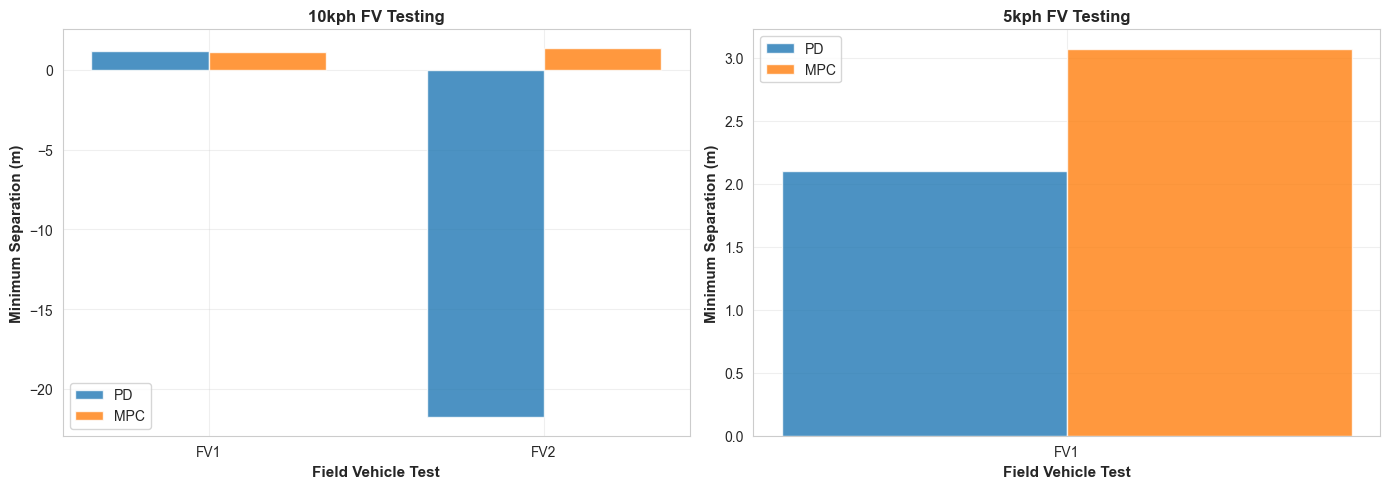

FV Plot 1: Separation Comparison - Complete


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, speed in enumerate(sorted(metrics_plot_fv_df['Speed'].unique())):
    speed_data = metrics_plot_fv_df[metrics_plot_fv_df['Speed'] == speed]
    pd_data = speed_data[speed_data['Type'] == 'PD'].sort_values('Test')
    mpc_data = speed_data[speed_data['Type'] == 'MPC'].sort_values('Test')

    # Use min count for bar alignment
    n_tests = min(len(pd_data), len(mpc_data))
    x = np.arange(n_tests)
    width = 0.35

    axes[idx].bar(x - width/2, pd_data['Min Separation'].values[:n_tests], width, label='PD', alpha=0.8, color='#1f77b4')
    axes[idx].bar(x + width/2, mpc_data['Min Separation'].values[:n_tests], width, label='MPC', alpha=0.8, color='#ff7f0e')

    axes[idx].set_xlabel('Field Vehicle Test', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Minimum Separation (m)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{speed} FV Testing', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels([f"FV{i+1}" for i in range(n_tests)])
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("FV Plot 1: Separation Comparison - Complete")


# FV PLOT 2: Smoothness Metrics

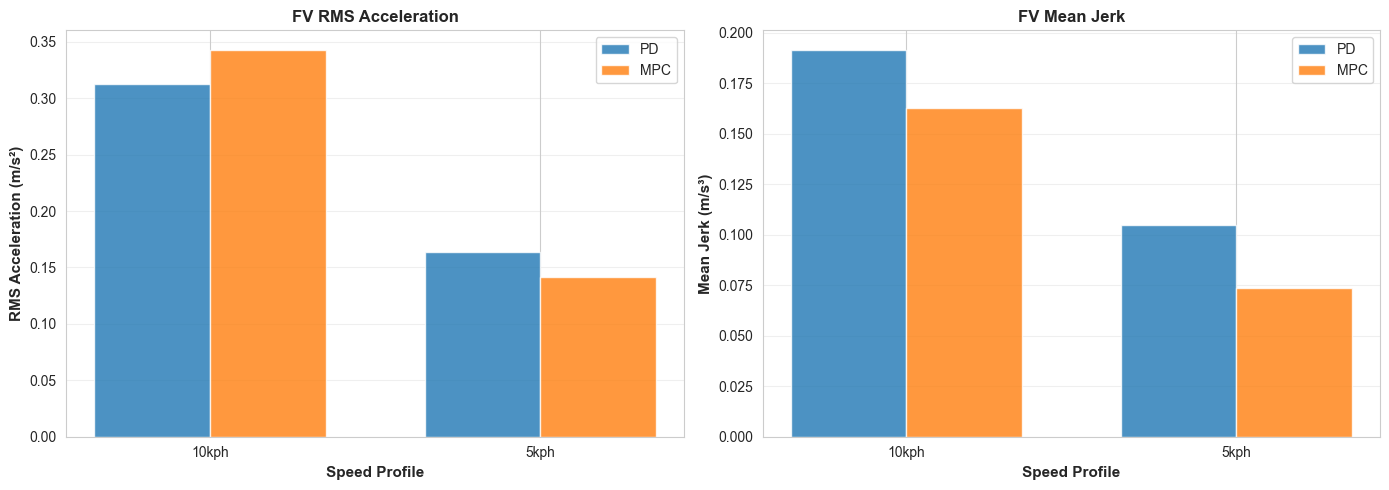

FV Plot 2: Smoothness Metrics - Complete


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, metric in enumerate(['RMS Acceleration', 'Mean Jerk']):
    speed_groups = sorted(metrics_plot_fv_df['Speed'].unique())
    pd_means = [metrics_plot_fv_df[(metrics_plot_fv_df['Speed'] == speed) & (metrics_plot_fv_df['Type'] == 'PD')][metric].mean() for speed in speed_groups]
    mpc_means = [metrics_plot_fv_df[(metrics_plot_fv_df['Speed'] == speed) & (metrics_plot_fv_df['Type'] == 'MPC')][metric].mean() for speed in speed_groups]

    x = np.arange(len(speed_groups))
    width = 0.35

    axes[idx].bar(x - width/2, pd_means, width, label='PD', alpha=0.8, color='#1f77b4')
    axes[idx].bar(x + width/2, mpc_means, width, label='MPC', alpha=0.8, color='#ff7f0e')

    axes[idx].set_xlabel('Speed Profile', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(metric + (' (m/s²)' if 'Accel' in metric else ' (m/s³)'), fontsize=11, fontweight='bold')
    axes[idx].set_title(f'FV {metric}', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(speed_groups)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("FV Plot 2: Smoothness Metrics - Complete")


# FV PLOT 3: Overshoot/Undershoot Comparison

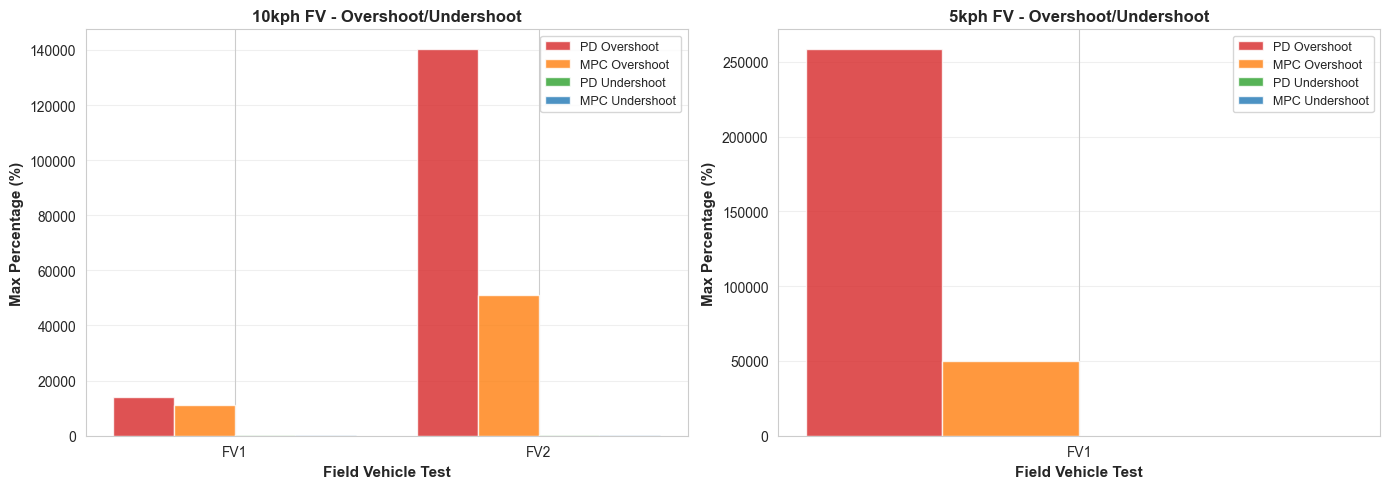

FV Plot 3: Overshoot/Undershoot - Complete


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, speed in enumerate(sorted(metrics_plot_fv_df['Speed'].unique())):
    speed_data = metrics_plot_fv_df[metrics_plot_fv_df['Speed'] == speed]
    pd_data = speed_data[speed_data['Type'] == 'PD'].sort_values('Test')
    mpc_data = speed_data[speed_data['Type'] == 'MPC'].sort_values('Test')

    n_tests = min(len(pd_data), len(mpc_data))
    x = np.arange(n_tests)
    width = 0.2

    axes[idx].bar(x - width*1.5, pd_data['Max Overshoot'].values[:n_tests], width, label='PD Overshoot', alpha=0.8, color='#d62728')
    axes[idx].bar(x - width*0.5, mpc_data['Max Overshoot'].values[:n_tests], width, label='MPC Overshoot', alpha=0.8, color='#ff7f0e')
    axes[idx].bar(x + width*0.5, pd_data['Max Undershoot'].values[:n_tests], width, label='PD Undershoot', alpha=0.8, color='#2ca02c')
    axes[idx].bar(x + width*1.5, mpc_data['Max Undershoot'].values[:n_tests], width, label='MPC Undershoot', alpha=0.8, color='#1f77b4')

    axes[idx].set_xlabel('Field Vehicle Test', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Max Percentage (%)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{speed} FV - Overshoot/Undershoot', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels([f"FV{i+1}" for i in range(n_tests)])
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("FV Plot 3: Overshoot/Undershoot - Complete")


# FV Summary Statistics

In [36]:
print("="*80)
print("FV TESTING: MPC vs PD PERFORMANCE SUMMARY")
print("="*80)

for speed in sorted(metrics_plot_fv_df['Speed'].unique()):
    speed_data = metrics_plot_fv_df[metrics_plot_fv_df['Speed'] == speed]

    print(f"\n{speed} Speed Profile:")
    print("-" * 60)

    pd_avg_sep = speed_data[speed_data['Type'] == 'PD']['Min Separation'].mean()
    mpc_avg_sep = speed_data[speed_data['Type'] == 'MPC']['Min Separation'].mean()
    sep_improvement = ((mpc_avg_sep - pd_avg_sep) / pd_avg_sep) * 100

    pd_avg_acc = speed_data[speed_data['Type'] == 'PD']['RMS Acceleration'].mean()
    mpc_avg_acc = speed_data[speed_data['Type'] == 'MPC']['RMS Acceleration'].mean()
    acc_improvement = ((pd_avg_acc - mpc_avg_acc) / pd_avg_acc) * 100

    pd_avg_jerk = speed_data[speed_data['Type'] == 'PD']['Mean Jerk'].mean()
    mpc_avg_jerk = speed_data[speed_data['Type'] == 'MPC']['Mean Jerk'].mean()
    jerk_improvement = ((pd_avg_jerk - mpc_avg_jerk) / pd_avg_jerk) * 100

    print(f"Min Separation: PD {pd_avg_sep:.2f}m vs MPC {mpc_avg_sep:.2f}m ({sep_improvement:+.1f}%)")
    print(f"RMS Acceleration: PD {pd_avg_acc:.4f} vs MPC {mpc_avg_acc:.4f} ({acc_improvement:+.1f}%)")
    print(f"Mean Jerk: PD {pd_avg_jerk:.4f} vs MPC {mpc_avg_jerk:.4f} ({jerk_improvement:+.1f}%)")

print("\n" + "="*80)
print("FV Field Vehicle Analysis Complete!")
print("="*80)


FV TESTING: MPC vs PD PERFORMANCE SUMMARY

10kph Speed Profile:
------------------------------------------------------------
Min Separation: PD -10.30m vs MPC 1.25m (-112.1%)
RMS Acceleration: PD 0.3122 vs MPC 0.3430 (-9.9%)
Mean Jerk: PD 0.1916 vs MPC 0.1627 (+15.1%)

5kph Speed Profile:
------------------------------------------------------------
Min Separation: PD 2.10m vs MPC 3.07m (+46.2%)
RMS Acceleration: PD 0.1638 vs MPC 0.1419 (+13.4%)
Mean Jerk: PD 0.1048 vs MPC 0.0735 (+29.9%)

FV Field Vehicle Analysis Complete!


# Jerk Analysis & Visualization

In [37]:
import numpy as np

def calculate_and_plot_jerk(pdc_df, mpc_df, pdc_file_name, mpc_file_name, speed_profile=""):
    '''Calculate jerk and create detailed comparison plots'''

    time_col = "Time(s)"
    acc_col = "Ego_Acceleration(m/s^2)"

    # PD Jerk Calculation
    pdc_acc = pdc_df[acc_col].values
    pdc_time = pdc_df[time_col].values
    pdc_dt = np.median(np.diff(pdc_time)[np.diff(pdc_time) > 0])
    pdc_jerk_raw = np.diff(pdc_acc) / pdc_dt
    pdc_jerk_time = pdc_time[:-1]
    pdc_jerk_smooth = np.convolve(pdc_jerk_raw, np.ones(3)/3, mode='same')

    # MPC Jerk Calculation
    mpc_acc = mpc_df[acc_col].values
    mpc_time = mpc_df[time_col].values
    mpc_dt = np.median(np.diff(mpc_time)[np.diff(mpc_time) > 0])
    mpc_jerk_raw = np.diff(mpc_acc) / mpc_dt
    mpc_jerk_time = mpc_time[:-1]
    mpc_jerk_smooth = np.convolve(mpc_jerk_raw, np.ones(3)/3, mode='same')

    # Statistics
    pdc_mean_jerk = np.mean(np.abs(pdc_jerk_raw))
    pdc_max_jerk = np.max(np.abs(pdc_jerk_raw))
    pdc_std_jerk = np.std(np.abs(pdc_jerk_raw))

    mpc_mean_jerk = np.mean(np.abs(mpc_jerk_raw))
    mpc_max_jerk = np.max(np.abs(mpc_jerk_raw))
    mpc_std_jerk = np.std(np.abs(mpc_jerk_raw))

    jerk_improvement = ((pdc_mean_jerk - mpc_mean_jerk) / pdc_mean_jerk) * 100

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # PD Jerk
    axes[0, 0].plot(pdc_jerk_time, pdc_jerk_raw, label="PD Jerk (Raw)",
                    color="tab:blue", linewidth=1, alpha=0.5)
    axes[0, 0].plot(pdc_jerk_time, pdc_jerk_smooth, label="PD Jerk (Smoothed)",
                    color="tab:red", linewidth=2)
    axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[0, 0].axhline(y=pdc_mean_jerk, color='green', linestyle='--',
                       label=f'Mean: {pdc_mean_jerk:.4f} m/s^3')
    axes[0, 0].set_ylabel("Jerk (m/s^3)", fontsize=11, fontweight='bold')
    axes[0, 0].set_title(f"PD Controller Jerk - {speed_profile}", fontsize=12, fontweight='bold')
    axes[0, 0].legend(loc='best', fontsize=9)
    axes[0, 0].grid(True, alpha=0.3)

    # MPC Jerk
    axes[0, 1].plot(mpc_jerk_time, mpc_jerk_raw, label="MPC Jerk (Raw)",
                    color="tab:orange", linewidth=1, alpha=0.5)
    axes[0, 1].plot(mpc_jerk_time, mpc_jerk_smooth, label="MPC Jerk (Smoothed)",
                    color="tab:red", linewidth=2)
    axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[0, 1].axhline(y=mpc_mean_jerk, color='green', linestyle='--',
                       label=f'Mean: {mpc_mean_jerk:.4f} m/s^3')
    axes[0, 1].set_ylabel("Jerk (m/s^3)", fontsize=11, fontweight='bold')
    axes[0, 1].set_title(f"MPC Controller Jerk - {speed_profile}", fontsize=12, fontweight='bold')
    axes[0, 1].legend(loc='best', fontsize=9)
    axes[0, 1].grid(True, alpha=0.3)

    # Absolute Jerk Comparison
    axes[1, 0].plot(pdc_jerk_time, np.abs(pdc_jerk_smooth), label="PD |Jerk|",
                    color="tab:blue", linewidth=2)
    axes[1, 0].plot(mpc_jerk_time, np.abs(mpc_jerk_smooth), label="MPC |Jerk|",
                    color="tab:orange", linewidth=2)
    axes[1, 0].fill_between(pdc_jerk_time, 0, np.abs(pdc_jerk_smooth),
                            alpha=0.1, color='blue')
    axes[1, 0].fill_between(mpc_jerk_time, 0, np.abs(mpc_jerk_smooth),
                            alpha=0.1, color='orange')
    axes[1, 0].set_xlabel("Time (s)", fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel("Absolute Jerk (m/s^3)", fontsize=11, fontweight='bold')
    axes[1, 0].set_title("Jerk Magnitude Comparison", fontsize=12, fontweight='bold')
    axes[1, 0].legend(loc='best', fontsize=9)
    axes[1, 0].grid(True, alpha=0.3)

    # Statistics Bar Chart
    metrics = ['Mean Jerk', 'Max Jerk', 'Std Dev']
    pdc_vals = [pdc_mean_jerk, pdc_max_jerk, pdc_std_jerk]
    mpc_vals = [mpc_mean_jerk, mpc_max_jerk, mpc_std_jerk]

    x = np.arange(len(metrics))
    width = 0.35

    axes[1, 1].bar(x - width/2, pdc_vals, width, label='PD', alpha=0.8, color='#1f77b4')
    axes[1, 1].bar(x + width/2, mpc_vals, width, label='MPC', alpha=0.8, color='#ff7f0e')

    axes[1, 1].set_ylabel("Jerk (m/s^3)", fontsize=11, fontweight='bold')
    axes[1, 1].set_title("Jerk Statistics", fontsize=12, fontweight='bold')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(metrics)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Print Statistics
    print("\n" + "="*70)
    print(f"JERK ANALYSIS: {speed_profile.upper()}")
    print("="*70)
    print(f"\nPD Controller ({pdc_file_name}):")
    print(f"  Mean Jerk:     {pdc_mean_jerk:.6f} m/s^3")
    print(f"  Max Jerk:      {pdc_max_jerk:.6f} m/s^3")
    print(f"  Std Dev Jerk:  {pdc_std_jerk:.6f} m/s^3")
    print(f"\nMPC Controller ({mpc_file_name}):")
    print(f"  Mean Jerk:     {mpc_mean_jerk:.6f} m/s^3")
    print(f"  Max Jerk:      {mpc_max_jerk:.6f} m/s^3")
    print(f"  Std Dev Jerk:  {mpc_std_jerk:.6f} m/s^3")
    print(f"\nMPC Improvement: {jerk_improvement:+.2f}% (Lower Jerk is Better)")
    print("="*70 + "\n")

    return {
        'pdc_mean': pdc_mean_jerk, 'pdc_max': pdc_max_jerk, 'pdc_std': pdc_std_jerk,
        'mpc_mean': mpc_mean_jerk, 'mpc_max': mpc_max_jerk, 'mpc_std': mpc_std_jerk,
        'improvement': jerk_improvement
    }

print("Jerk plotting function defined")


Jerk plotting function defined


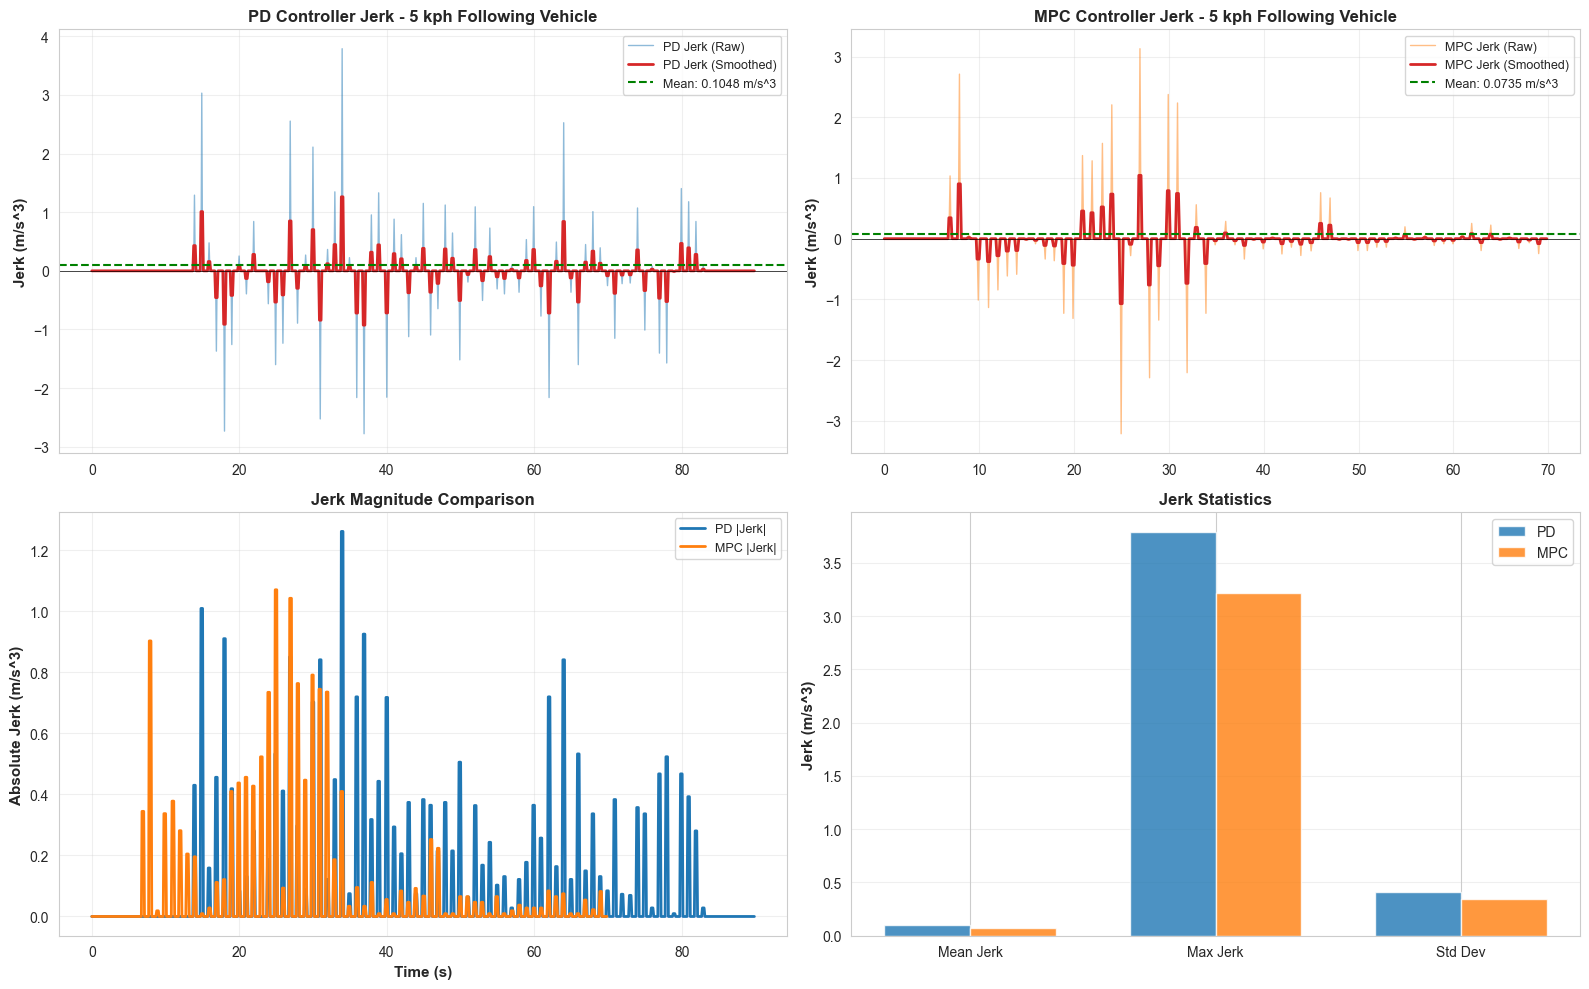


JERK ANALYSIS: 5 KPH FOLLOWING VEHICLE

PD Controller (Data_Jun4_PD_5kph_FV1.csv):
  Mean Jerk:     0.104834 m/s^3
  Max Jerk:      3.787579 m/s^3
  Std Dev Jerk:  0.406716 m/s^3

MPC Controller (Data_Apr7_MPC_5kph_FV1.csv):
  Mean Jerk:     0.073533 m/s^3
  Max Jerk:      3.213550 m/s^3
  Std Dev Jerk:  0.347358 m/s^3

MPC Improvement: +29.86% (Lower Jerk is Better)



In [38]:
# JERK ANALYSIS - 5 KPH FOLLOWING VEHICLE SCENARIO

# Get 5 kph files
pdc_5kph_fv_files = [f for f in os.listdir(internal_PDC_FV_data_dir) if '5kph' in f]
mpc_5kph_fv_files = [f for f in os.listdir(internal_MPC_FV_data_dir) if '5kph' in f]

if pdc_5kph_fv_files and mpc_5kph_fv_files:
    pdc_5kph_file = os.path.join(internal_PDC_FV_data_dir, pdc_5kph_fv_files[0])
    mpc_5kph_file = os.path.join(internal_MPC_FV_data_dir, mpc_5kph_fv_files[0])

    pdc_5kph_df = pd.read_csv(pdc_5kph_file)
    mpc_5kph_df = pd.read_csv(mpc_5kph_file)

    jerk_stats_5kph = calculate_and_plot_jerk(
        pdc_5kph_df,
        mpc_5kph_df,
        os.path.basename(pdc_5kph_file),
        os.path.basename(mpc_5kph_file),
        speed_profile="5 kph Following Vehicle"
    )


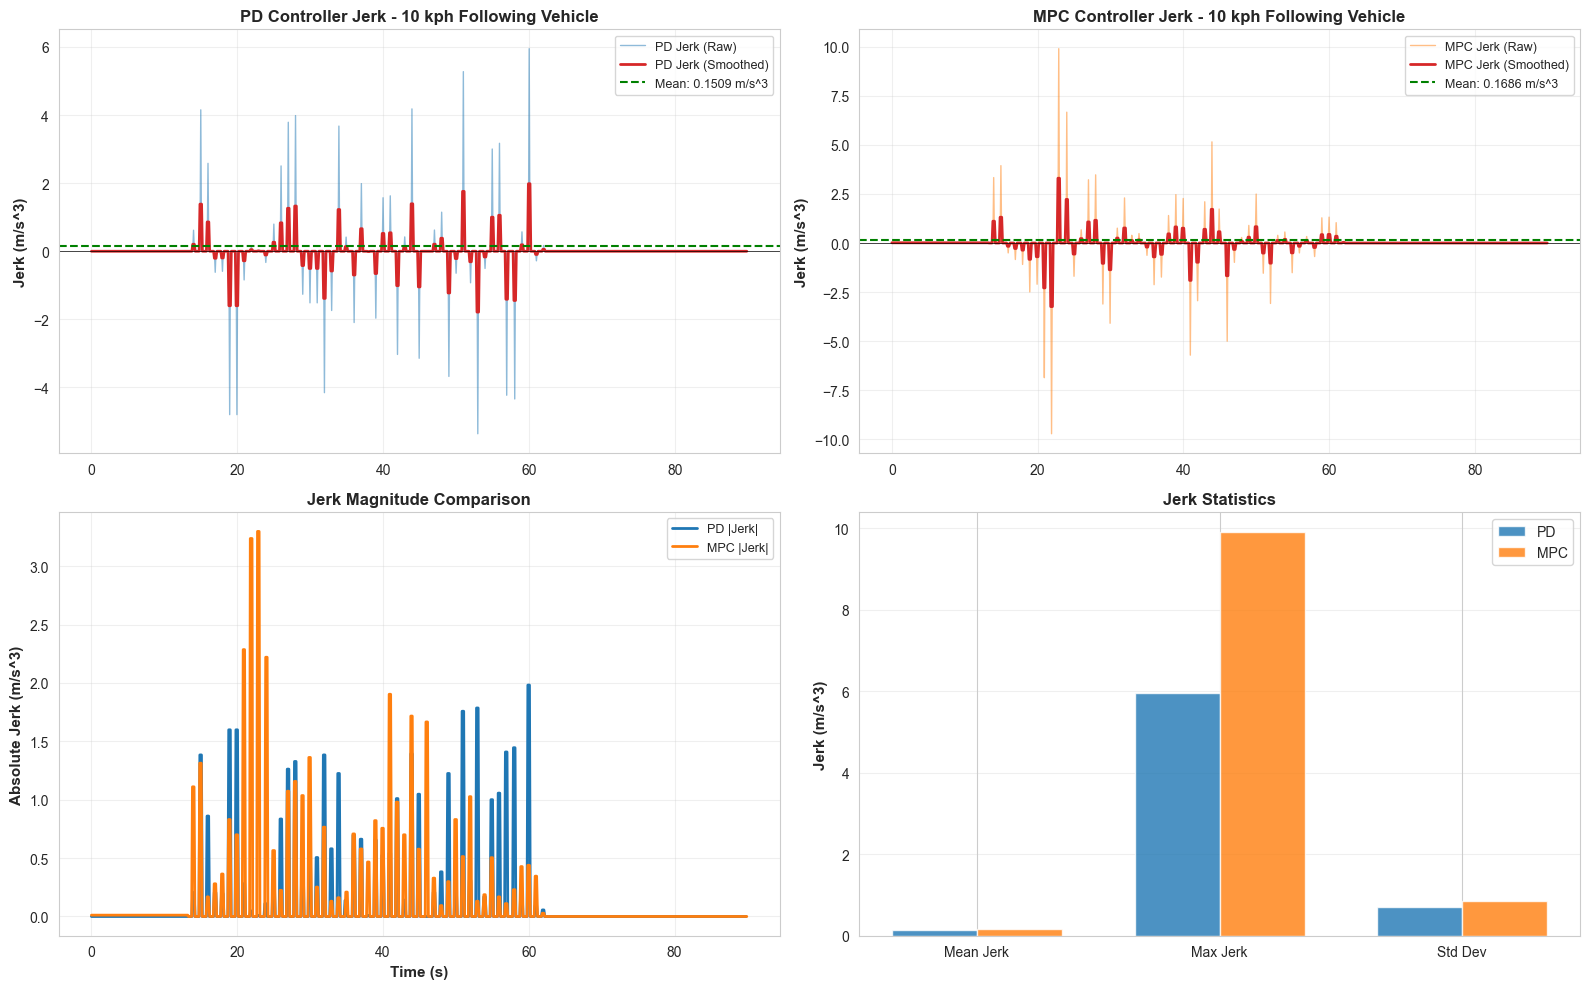


JERK ANALYSIS: 10 KPH FOLLOWING VEHICLE

PD Controller (Data_Jun4_PD_10kph_FV1.csv):
  Mean Jerk:     0.150918 m/s^3
  Max Jerk:      5.947450 m/s^3
  Std Dev Jerk:  0.712317 m/s^3

MPC Controller (Data_Jun4_MPC_10kph_FV1.csv):
  Mean Jerk:     0.168607 m/s^3
  Max Jerk:      9.895541 m/s^3
  Std Dev Jerk:  0.854797 m/s^3

MPC Improvement: -11.72% (Lower Jerk is Better)



In [39]:
# JERK ANALYSIS - 10 KPH FOLLOWING VEHICLE SCENARIO

# Get 10 kph files
pdc_10kph_fv_files = [f for f in os.listdir(internal_PDC_FV_data_dir) if '10kph' in f]
mpc_10kph_fv_files = [f for f in os.listdir(internal_MPC_FV_data_dir) if '10kph' in f]

if pdc_10kph_fv_files and mpc_10kph_fv_files:
    pdc_10kph_file = os.path.join(internal_PDC_FV_data_dir, pdc_10kph_fv_files[0])
    mpc_10kph_file = os.path.join(internal_MPC_FV_data_dir, mpc_10kph_fv_files[0])

    pdc_10kph_df = pd.read_csv(pdc_10kph_file)
    mpc_10kph_df = pd.read_csv(mpc_10kph_file)

    jerk_stats_10kph = calculate_and_plot_jerk(
        pdc_10kph_df,
        mpc_10kph_df,
        os.path.basename(pdc_10kph_file),
        os.path.basename(mpc_10kph_file),
        speed_profile="10 kph Following Vehicle"
    )


### Energy Consumption Calculations (FV Scenario)

In [40]:
import numpy as np

def calculate_energy_consumption(df, mass_kg=680, mu_rolling=0.015, g=9.81, time_limit_s=50):
    '''Calculate energy consumption for first 50 seconds (1 Hz resampled sampling).'''

    # Filter data to first 50 seconds only
    df_filtered = df[df['Time(s)'] <= time_limit_s].copy()

    if len(df_filtered) < 2:
        print(f"  [WARNING] Not enough data within {time_limit_s}s limit")
        return None

    # Resample to uniform 1 Hz frequency for fair comparison
    time_orig = df_filtered['Time(s)'].values
    time_resampled = np.arange(0, time_limit_s + 1, 1)
    time_resampled = time_resampled[time_resampled <= time_limit_s]

    # Interpolate acceleration and velocity to common time grid
    accel_orig = df_filtered['Ego_Acceleration(m/s^2)'].values
    accel_resampled = np.interp(time_resampled, time_orig, accel_orig)

    velocity_kmph_orig = df_filtered['Ego_Velocity_kmph'].values
    velocity_kmph_resampled = np.interp(time_resampled, time_orig, velocity_kmph_orig)
    velocity_resampled = velocity_kmph_resampled / 3.6  # Convert to m/s

    time = time_resampled
    accel = accel_resampled
    velocity = velocity_resampled

    # Calculate time intervals
    dt = np.diff(time)

    # Rolling friction force (constant)
    F_friction = mu_rolling * mass_kg * g

    # Acceleration force
    F_accel = mass_kg * accel

    # Total driving force
    F_total = F_accel + F_friction

    # Power = Force x Velocity (Watts)
    power = F_total * velocity
    power = np.maximum(power, 0)

    # Energy = integral Power dt using trapezoidal rule
    power_intervals = (power[:-1] + power[1:]) / 2
    energy_interval = power_intervals * dt
    total_energy_j = np.sum(energy_interval)

    # Breakdown: Acceleration energy
    power_accel = mass_kg * accel * velocity
    power_accel = np.maximum(power_accel, 0)
    power_accel_intervals = (power_accel[:-1] + power_accel[1:]) / 2
    energy_accel_j = np.sum(power_accel_intervals * dt)

    # Breakdown: Friction energy
    power_friction = F_friction * velocity
    power_friction_intervals = (power_friction[:-1] + power_friction[1:]) / 2
    energy_friction_j = np.sum(power_friction_intervals * dt)

    # Statistics
    avg_power = total_energy_j / (time[-1] - time[0]) if len(time) > 1 else 0
    peak_power = np.max(power)

    return {
        'total_energy_j': total_energy_j,
        'total_energy_kj': total_energy_j / 1000,
        'total_energy_kwh': total_energy_j / 3.6e6,
        'energy_accel_kj': energy_accel_j / 1000,
        'energy_friction_kj': energy_friction_j / 1000,
        'avg_power_w': avg_power,
        'peak_power_w': peak_power,
        'time_duration_s': time[-1] - time[0],
        'actual_samples': len(time),
        'sampling_freq_hz': 1.0,
    }

print("Energy consumption function defined (1 Hz resampled)")


Energy consumption function defined (1 Hz resampled)


In [41]:
# ENERGY CONSUMPTION - 5 KPH FOLLOWING VEHICLE SCENARIO

import re

# Get 5 kph files from both controllers
pdc_5kph_fv_files = [f for f in os.listdir(internal_PDC_FV_data_dir) if '5kph' in f]
mpc_5kph_fv_files = [f for f in os.listdir(internal_MPC_FV_data_dir) if '5kph' in f]

print(f"PD 5kph FV files: {pdc_5kph_fv_files}")
print(f"MPC 5kph FV files: {mpc_5kph_fv_files}")

if pdc_5kph_fv_files and mpc_5kph_fv_files:
    all_energy_results_5kph = []

    for pdc_file in pdc_5kph_fv_files:
        for mpc_file in mpc_5kph_fv_files:
            pdc_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, pdc_file))
            mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir, mpc_file))

            pdc_energy = calculate_energy_consumption(pdc_df, time_limit_s=50)
            mpc_energy = calculate_energy_consumption(mpc_df, time_limit_s=50)

            if pdc_energy is not None and mpc_energy is not None:
                energy_improvement = ((pdc_energy['total_energy_kj'] - mpc_energy['total_energy_kj']) / pdc_energy['total_energy_kj']) * 100

                print(f"\n5 kph FV - {pdc_file} vs {mpc_file}")
                print(f"  PD Energy: {pdc_energy['total_energy_kj']:.2f} kJ | Avg Power: {pdc_energy['avg_power_w']:.2f} W")
                print(f"  MPC Energy: {mpc_energy['total_energy_kj']:.2f} kJ | Avg Power: {mpc_energy['avg_power_w']:.2f} W")
                print(f"  Energy Improvement: {energy_improvement:+.2f}%")

                all_energy_results_5kph.append({
                    'Speed': '5kph',
                    'PD Energy (kJ)': pdc_energy['total_energy_kj'],
                    'MPC Energy (kJ)': mpc_energy['total_energy_kj'],
                    'PD Avg Power (W)': pdc_energy['avg_power_w'],
                    'MPC Avg Power (W)': mpc_energy['avg_power_w'],
                    'Improvement (%)': energy_improvement,
                })

    if all_energy_results_5kph:
        energy_df_5kph = pd.DataFrame(all_energy_results_5kph)
        print("\n" + "="*90)
        print("5 kph FV Energy Results")
        print("="*90)
        print(energy_df_5kph.to_string(index=False))


PD 5kph FV files: ['Data_Jun4_PD_5kph_FV1.csv']
MPC 5kph FV files: ['Data_Apr7_MPC_5kph_FV1.csv']

5 kph FV - Data_Jun4_PD_5kph_FV1.csv vs Data_Apr7_MPC_5kph_FV1.csv
  PD Energy: 5.12 kJ | Avg Power: 102.41 W
  MPC Energy: 5.63 kJ | Avg Power: 112.59 W
  Energy Improvement: -9.94%

5 kph FV Energy Results
Speed  PD Energy (kJ)  MPC Energy (kJ)  PD Avg Power (W)  MPC Avg Power (W)  Improvement (%)
 5kph        5.120314         5.629328        102.406278         112.586561        -9.941073


In [42]:
# ENERGY CONSUMPTION - 10 KPH FOLLOWING VEHICLE SCENARIO

# Get 10 kph files from both controllers
pdc_10kph_fv_files = [f for f in os.listdir(internal_PDC_FV_data_dir) if '10kph' in f]
mpc_10kph_fv_files = [f for f in os.listdir(internal_MPC_FV_data_dir) if '10kph' in f]

print(f"PD 10kph FV files: {pdc_10kph_fv_files}")
print(f"MPC 10kph FV files: {mpc_10kph_fv_files}")

if pdc_10kph_fv_files and mpc_10kph_fv_files:
    all_energy_results_10kph = []

    for pdc_file in pdc_10kph_fv_files:
        for mpc_file in mpc_10kph_fv_files:
            pdc_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, pdc_file))
            mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir, mpc_file))

            pdc_energy = calculate_energy_consumption(pdc_df, time_limit_s=50)
            mpc_energy = calculate_energy_consumption(mpc_df, time_limit_s=50)

            if pdc_energy is not None and mpc_energy is not None:
                energy_improvement = ((pdc_energy['total_energy_kj'] - mpc_energy['total_energy_kj']) / pdc_energy['total_energy_kj']) * 100

                print(f"\n10 kph FV - {pdc_file} vs {mpc_file}")
                print(f"  PD Energy: {pdc_energy['total_energy_kj']:.2f} kJ | Avg Power: {pdc_energy['avg_power_w']:.2f} W")
                print(f"  MPC Energy: {mpc_energy['total_energy_kj']:.2f} kJ | Avg Power: {mpc_energy['avg_power_w']:.2f} W")
                print(f"  Energy Improvement: {energy_improvement:+.2f}%")

                all_energy_results_10kph.append({
                    'Speed': '10kph',
                    'PD Energy (kJ)': pdc_energy['total_energy_kj'],
                    'MPC Energy (kJ)': mpc_energy['total_energy_kj'],
                    'PD Avg Power (W)': pdc_energy['avg_power_w'],
                    'MPC Avg Power (W)': mpc_energy['avg_power_w'],
                    'Improvement (%)': energy_improvement,
                })

    if all_energy_results_10kph:
        energy_df_10kph = pd.DataFrame(all_energy_results_10kph)
        print("\n" + "="*90)
        print("10 kph FV Energy Results")
        print("="*90)
        print(energy_df_10kph.to_string(index=False))


PD 10kph FV files: ['Data_Jun4_PD_10kph_FV1.csv', 'Data_Jun4_PD_10kph_FV2.csv']
MPC 10kph FV files: ['Data_Jun4_MPC_10kph_FV1.csv', 'Data_Jun4_MPC_10kph_FV2.csv']

10 kph FV - Data_Jun4_PD_10kph_FV1.csv vs Data_Jun4_MPC_10kph_FV1.csv
  PD Energy: 10.75 kJ | Avg Power: 215.02 W
  MPC Energy: 13.51 kJ | Avg Power: 270.13 W
  Energy Improvement: -25.63%

10 kph FV - Data_Jun4_PD_10kph_FV1.csv vs Data_Jun4_MPC_10kph_FV2.csv
  PD Energy: 10.75 kJ | Avg Power: 215.02 W
  MPC Energy: 9.71 kJ | Avg Power: 194.22 W
  Energy Improvement: +9.68%

10 kph FV - Data_Jun4_PD_10kph_FV2.csv vs Data_Jun4_MPC_10kph_FV1.csv
  PD Energy: 8.35 kJ | Avg Power: 166.99 W
  MPC Energy: 13.51 kJ | Avg Power: 270.13 W
  Energy Improvement: -61.77%

10 kph FV - Data_Jun4_PD_10kph_FV2.csv vs Data_Jun4_MPC_10kph_FV2.csv
  PD Energy: 8.35 kJ | Avg Power: 166.99 W
  MPC Energy: 9.71 kJ | Avg Power: 194.22 W
  Energy Improvement: -16.31%

10 kph FV Energy Results
Speed  PD Energy (kJ)  MPC Energy (kJ)  PD Avg Power (W)